<a href="https://colab.research.google.com/github/paulsurya/Vel-Tech-Summer-Internship/blob/main/Stock_Trend_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [23]:
!pip install yfinance ta xgboost scikit-learn matplotlib seaborn --quiet

In [24]:
import yfinance as yf
import pandas as pd
import numpy as np
import ta
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score
)
from sklearn.preprocessing import LabelEncoder

In [25]:
# NSE tickers use '.NS' suffix on Yahoo Finance
TICKERS = ['ADANIPORTS.NS', 'RELIANCE.NS']

def download_data(ticker):
    print(f'Downloading data for {ticker}...')
    df = yf.download(ticker, period='1y', interval='1d', auto_adjust=True)

    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)

    # Keep only OHLCV columns
    df = df[['Open', 'High', 'Low', 'Close', 'Volume']]
    df.dropna(inplace=True)
    print(f'  \u2192 {len(df)} trading days downloaded')
    print(f'  \u2192 Columns: {list(df.columns)}')
    return df

data = {ticker: download_data(ticker) for ticker in TICKERS}

data['ADANIPORTS.NS'].head()

[*********************100%***********************]  1 of 1 completed

  → 250 trading days downloaded
  → Columns: ['Open', 'High', 'Low', 'Close', 'Volume']



[*********************100%***********************]  1 of 1 completed

  → 250 trading days downloaded
  → Columns: ['Open', 'High', 'Low', 'Close', 'Volume']


Price,Open,High,Low,Close,Volume
Date,,,,,
2025-06-05,1436.809649,1460.593836,1431.037682,1449.647095,2019939
2025-06-06,1449.647209,1471.739798,1446.661734,1464.574585,1269864
2025-06-09,1474.824710,1476.815027,1456.016193,1459.996826,1493331
2025-06-10,1464.873095,1486.766579,1462.683795,1466.664429,2125187
2025-06-11,1466.664412,1468.853712,1441.785454,1449.348633,2192673


In [38]:
def add_features(df):
    df = df.copy()

    # Moving Averages
    df['SMA_10'] = ta.trend.sma_indicator(df['Close'], window=10)
    df['SMA_20'] = ta.trend.sma_indicator(df['Close'], window=20)
    df['EMA_10'] = ta.trend.ema_indicator(df['Close'], window=10)

    # RSI (Relative Strength Index)
    df['RSI'] = ta.momentum.rsi(df['Close'], window=14)

    # MACD
    macd_obj = ta.trend.MACD(df['Close'])
    df['MACD']        = macd_obj.macd()
    df['MACD_Signal'] = macd_obj.macd_signal()
    df['MACD_Hist']   = macd_obj.macd_diff()

    # Bollinger Bands
    bb_obj = ta.volatility.BollingerBands(df['Close'], window=20)
    df['BB_Upper'] = bb_obj.bollinger_hband()
    df['BB_Lower'] = bb_obj.bollinger_lband()
    df['BB_Width'] = bb_obj.bollinger_wband()

    # Volume Change (%)
    df['Volume_Change'] = df['Volume'].pct_change() * 100

    # Price Change (%)
    df['Price_Change'] = df['Close'].pct_change() * 100

    # High-Low Range
    df['HL_Range'] = df['High'] - df['Low']

    # Average True Range — measures volatility
    df['ATR'] = ta.volatility.AverageTrueRange(
        df['High'], df['Low'], df['Close'], window=14
    ).average_true_range()

    # On Balance Volume — tracks buying/selling pressure
    df['OBV'] = ta.volume.OnBalanceVolumeIndicator(
        df['Close'], df['Volume']
    ).on_balance_volume()

    # Williams %R — momentum oscillator
    df['Williams_R'] = ta.momentum.WilliamsRIndicator(
        df['High'], df['Low'], df['Close'], lbp=14
    ).williams_r()

    df.replace([np.inf, -np.inf], np.nan, inplace=True)
    df.dropna(inplace=True)
    return df

for ticker in TICKERS:
    data[ticker] = add_features(data[ticker])

for ticker in TICKERS:
    df = data[ticker]
    n_inf = np.isinf(df.select_dtypes(include=np.number)).sum().sum()
    n_nan = df.isna().sum().sum()
    print(f'{ticker} — inf values: {n_inf} | NaN values: {n_nan} | Rows: {len(df)}')

print('\n✅ Features added and data is clean!')

ADANIPORTS.NS — inf values: 0 | NaN values: 0 | Rows: 141
RELIANCE.NS — inf values: 0 | NaN values: 0 | Rows: 141

✅ Features added and data is clean!


In [39]:
def generate_labels(df, threshold=0.3):
    df = df.copy()

    # ✅ Correct: % change from today's close to tomorrow's close
    df['Next_Return'] = (df['Close'].shift(-1) - df['Close']) / df['Close'] * 100

    # Classify into Up / Down / Neutral
    def classify(ret):
        if ret > threshold:
            return 'Up'
        elif ret < -threshold:
            return 'Down'
        else:
            return 'Neutral'

    df['Trend'] = df['Next_Return'].apply(classify)

    # Drop last row (no next day data) and the helper column
    df.dropna(inplace=True)
    df.drop(columns=['Next_Return'], inplace=True)
    return df

for ticker in TICKERS:
    data[ticker] = generate_labels(data[ticker])

# Show label distribution for ADANIPORTS
print('📊 ADANIPORTS — Trend Distribution:')
print(data['ADANIPORTS.NS']['Trend'].value_counts())

print('\n📊 RELIANCE — Trend Distribution:')
print(data['RELIANCE.NS']['Trend'].value_counts())

📊 ADANIPORTS — Trend Distribution:
Trend
Up         62
Down       56
Neutral    22
Name: count, dtype: int64

📊 RELIANCE — Trend Distribution:
Trend
Down       54
Up         51
Neutral    35
Name: count, dtype: int64


In [40]:
FEATURE_COLS = [
    'Open', 'High', 'Low', 'Close', 'Volume',
    'SMA_10', 'SMA_20', 'EMA_10',
    'RSI', 'MACD', 'MACD_Signal', 'MACD_Hist',
    'BB_Upper', 'BB_Lower', 'BB_Width',
    'Volume_Change', 'Price_Change', 'HL_Range',
    'ATR', 'OBV', 'Williams_R'
]

def split_data(df):
    X = df[FEATURE_COLS]
    y = df['Trend']

    # Chronological split — no shuffling!
    split_idx = int(len(df) * 0.8)
    X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
    y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

    print(f'  Train: {len(X_train)} samples | Test: {len(X_test)} samples')
    return X_train, X_test, y_train, y_test

print('ADANIPORTS:')
X_train_a, X_test_a, y_train_a, y_test_a = split_data(data['ADANIPORTS.NS'])

print('RELIANCE:')
X_train_r, X_test_r, y_train_r, y_test_r = split_data(data['RELIANCE.NS'])

print('\n✅ Data split complete!')

ADANIPORTS:
  Train: 112 samples | Test: 28 samples
RELIANCE:
  Train: 112 samples | Test: 28 samples

✅ Data split complete!


In [41]:
def train_xgboost(X_train, y_train):
    # Encode string labels to integers
    le = LabelEncoder()
    y_encoded = le.fit_transform(y_train)

    # ✅ Final safety check — remove any remaining inf/NaN before training
    X_train = X_train.replace([np.inf, -np.inf], np.nan)
    mask = ~X_train.isna().any(axis=1)
    X_train = X_train[mask]
    y_encoded = y_encoded[mask]
    print(f'  → Training on {len(X_train)} clean rows')

    model = xgb.XGBClassifier(
        n_estimators=300,        # more trees
        max_depth=3,             # shallower = less overfitting
        learning_rate=0.03,      # slower, more careful learning
        subsample=0.7,
        colsample_bytree=0.7,    # use 70% of features per tree
        min_child_weight=5,      # prevents splits on tiny groups
        gamma=0.2,               # minimum gain to make a split
        reg_alpha=0.1,           # L1 regularisation
        reg_lambda=1.5,          # L2 regularisation
        eval_metric='mlogloss',
        random_state=42
    )

    model.fit(X_train, y_encoded)
    return model, le

print('Training model for ADANIPORTS...')
model_a, le_a = train_xgboost(X_train_a, y_train_a)
print('  ✅ Done!')

print('Training model for RELIANCE...')
model_r, le_r = train_xgboost(X_train_r, y_train_r)
print('  ✅ Done!')

Training model for ADANIPORTS...
  → Training on 112 clean rows
  ✅ Done!
Training model for RELIANCE...
  → Training on 112 clean rows
  ✅ Done!


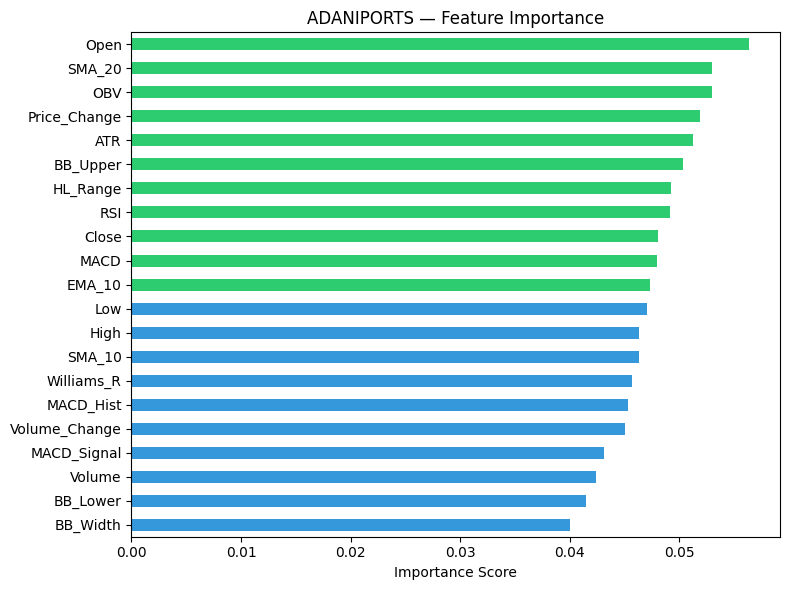

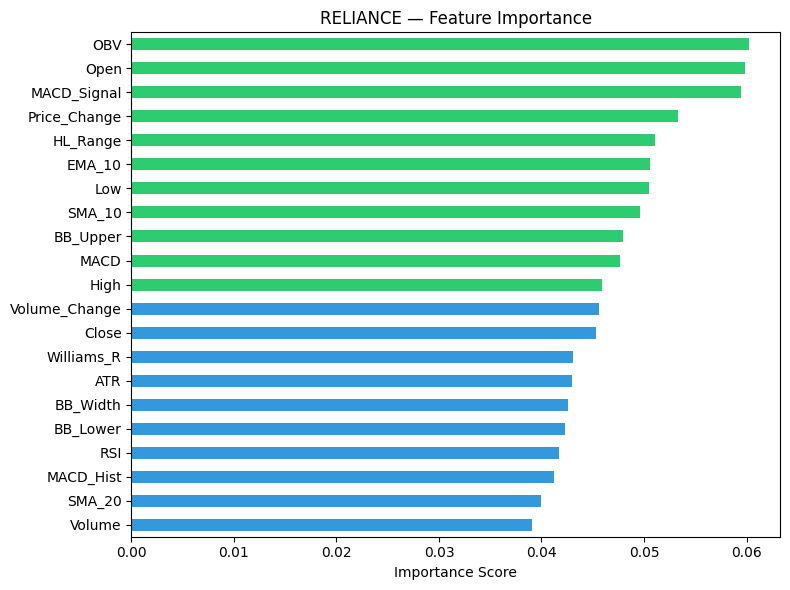

In [43]:
def plot_feature_importance(model, ticker_name):
    importance = pd.Series(
        model.feature_importances_,
        index=FEATURE_COLS
    ).sort_values(ascending=True)

    # Filter out zero-importance features for a cleaner chart
    importance = importance[importance > 0]

    plt.figure(figsize=(8, 6))
    colors = ['#2ecc71' if v >= importance.median() else '#3498db' for v in importance]
    importance.plot(kind='barh', color=colors)
    plt.title(f'{ticker_name} — Feature Importance')
    plt.xlabel('Importance Score')
    plt.xlim(left=0)  # always start from 0
    plt.tight_layout()
    plt.show()

plot_feature_importance(model_a, 'ADANIPORTS')
plot_feature_importance(model_r, 'RELIANCE')